# 🤖 SatEnergy — Notebook 03: Modelo de Previsão de Geração Renovável

**Objetivo:** Treinar modelos de Machine Learning para prever o fator de capacidade de geração solar e eólica, incorporando dados climáticos da NASA POWER e Copernicus ERA5.

| Etapa | Descrição |
|-------|-----------|
| 1 | Carregamento e feature engineering |
| 2 | Dados climáticos — NASA POWER API |
| 3 | Dados climáticos — Copernicus ERA5 |
| 4 | Treinamento dos modelos (XGBoost) |
| 5 | Avaliação e comparativo de performance |
| 6 | Importância das variáveis |

## 0. Imports e Configuração

In [95]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
import glob
import joblib
import zipfile
import netCDF4 as nc
import cdsapi

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 1. Carregando e Preparando os Dados ONS

In [96]:
arquivos = glob.glob('../data/raw/FATOR*.csv')
df = pd.read_csv(arquivos[0], sep=';', encoding='utf-8')
df['din_instante'] = pd.to_datetime(df['din_instante'])

def criar_features(df):
    df = df.copy()
    df['hora']       = df['din_instante'].dt.hour
    df['mes']        = df['din_instante'].dt.month
    df['dia_semana'] = df['din_instante'].dt.dayofweek
    df['dia_ano']    = df['din_instante'].dt.dayofyear
    df['trimestre']  = df['din_instante'].dt.quarter
    df['hora_sin']     = np.sin(2 * np.pi * df['hora'] / 24)
    df['hora_cos']     = np.cos(2 * np.pi * df['hora'] / 24)
    df['mes_sin']      = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos']      = np.cos(2 * np.pi * df['mes'] / 12)
    df['dia_ano_sin']  = np.sin(2 * np.pi * df['dia_ano'] / 365)
    df['dia_ano_cos']  = np.cos(2 * np.pi * df['dia_ano'] / 365)
    df['latitude']   = df['val_latitudesecoletora']
    df['longitude']  = df['val_longitudesecoletora']
    df['capacidade'] = df['val_capacidadeinstalada']
    le_sub   = LabelEncoder()
    le_estado = LabelEncoder()
    df['subsistema_enc'] = le_sub.fit_transform(df['nom_subsistema'].astype(str))
    df['estado_enc']     = le_estado.fit_transform(df['nom_estado'].astype(str))
    return df

df = criar_features(df)
df_solar  = df[df['nom_tipousina'] == 'Solar'].copy()
df_eolica = df[df['nom_tipousina'] == 'Eólica'].copy()

print(f'✅ {len(df):,} registros carregados')
print(f'   Solar:  {len(df_solar):,} registros')
print(f'   Eólica: {len(df_eolica):,} registros')

✅ 166,320 registros carregados
   Solar:  56,160 registros
   Eólica: 110,160 registros


## 2. NASA POWER API — Dados de Irradiância e Temperatura

In [97]:
regioes = {
    'Nordeste':     (-8.0,  -40.0),
    'Sudeste':      (-20.0, -45.0),
    'Sul':          (-28.0, -52.0),
    'Norte':        (-5.0,  -60.0),
    'Centro-Oeste': (-15.0, -55.0),
}

dfs_nasa = []
for regiao, (lat, lon) in regioes.items():
    print(f'⏳ Baixando {regiao}...')
    url = (
        f'https://power.larc.nasa.gov/api/temporal/hourly/point?'
        f'parameters=ALLSKY_SFC_SW_DWN,T2M,WS10M,CLOUD_AMT'
        f'&community=RE&longitude={lon}&latitude={lat}'
        f'&start=20240101&end=20240131&format=JSON'
    )
    r = requests.get(url, timeout=60)
    if r.status_code == 200:
        dados = r.json()
        params = dados['properties']['parameter']
        df_temp = pd.DataFrame(params)
        df_temp.index = pd.to_datetime(df_temp.index, format='%Y%m%d%H')
        df_temp = df_temp.reset_index()
        df_temp.columns = ['din_instante', 'irradiancia_nasa', 'temperatura_c', 'vento_nasa_ms', 'nuvens_pct']
        df_temp['irradiancia_nasa'] = df_temp['irradiancia_nasa'].replace(-999.0, np.nan)
        df_temp['nuvens_pct']       = df_temp['nuvens_pct'].replace(-999.0, np.nan)
        df_temp['regiao']    = regiao
        df_temp['hora']      = df_temp['din_instante'].dt.hour
        dfs_nasa.append(df_temp)
        print(f'  ✅ {len(df_temp)} registros')

df_nasa = pd.concat(dfs_nasa, ignore_index=True)
df_nasa.to_csv('../data/processed/nasa_power_climatico.csv', index=False)
print(f'\n✅ Total NASA: {len(df_nasa):,} registros salvos!')

⏳ Baixando Nordeste...
  ✅ 744 registros
⏳ Baixando Sudeste...
  ✅ 744 registros
⏳ Baixando Sul...
  ✅ 744 registros
⏳ Baixando Norte...
  ✅ 744 registros
⏳ Baixando Centro-Oeste...
  ✅ 744 registros

✅ Total NASA: 3,720 registros salvos!


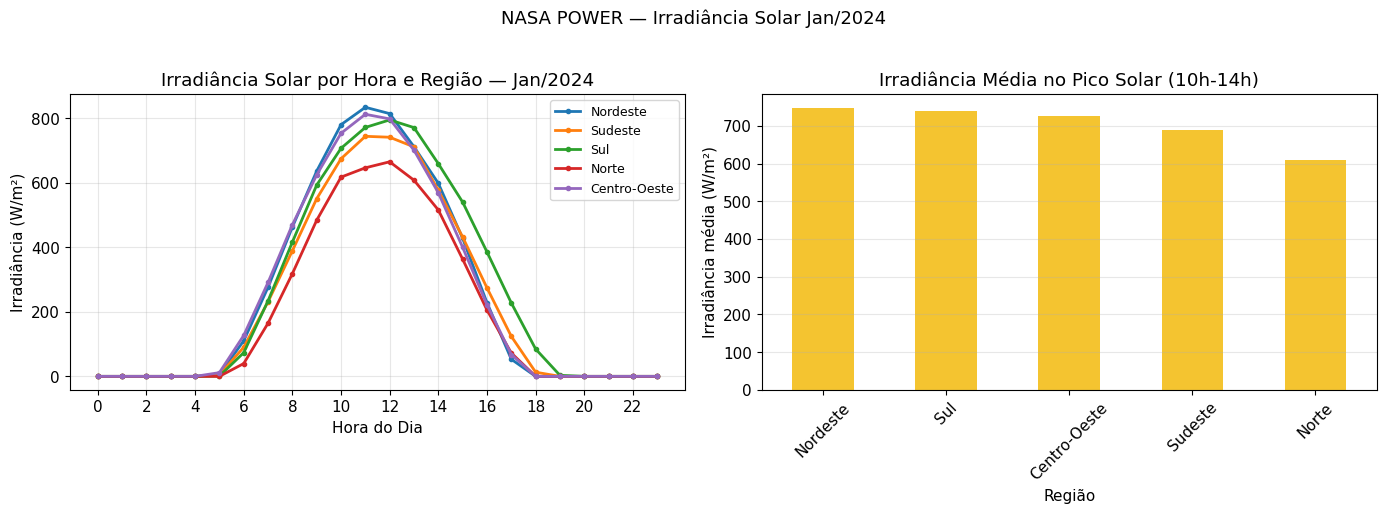

✅ Gráfico NASA salvo!


In [98]:
# Visualizando dados NASA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for regiao in df_nasa['regiao'].unique():
    subset = df_nasa[df_nasa['regiao'] == regiao].groupby('hora')['irradiancia_nasa'].mean()
    axes[0].plot(subset.index, subset.values, linewidth=2, marker='o', markersize=3, label=regiao)
axes[0].set_title('Irradiância Solar por Hora e Região — Jan/2024')
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('Irradiância (W/m²)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

pico = df_nasa[df_nasa['hora'].between(10, 14)]
nasa_pico = pico.groupby('regiao')['irradiancia_nasa'].mean().sort_values(ascending=False)
nasa_pico.plot(kind='bar', ax=axes[1], color='#f4c430')
axes[1].set_title('Irradiância Média no Pico Solar (10h-14h)')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Irradiância média (W/m²)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('NASA POWER — Irradiância Solar Jan/2024', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/nasa_irradiancia.png', dpi=150)
plt.show()
print('✅ Gráfico NASA salvo!')

## 3. Copernicus ERA5 — Dados de Vento

In [99]:
# Baixando dados ERA5 (só roda se o arquivo não existir)
import os

arquivo_era5 = '../data/raw/era5_brasil_jan2024.nc'

if not os.path.exists(arquivo_era5):
    print('⏳ Baixando ERA5 do Copernicus...')
    client = cdsapi.Client()
    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'variable': [
                '10m_u_component_of_wind',
                '10m_v_component_of_wind',
                '100m_u_component_of_wind',
                '100m_v_component_of_wind',
                'surface_solar_radiation_downwards',
            ],
            'year': '2024',
            'month': '01',
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': [f'{h:02d}:00' for h in range(0, 24)],
            'area': [5, -74, -34, -28],
            'format': 'netcdf',
        },
        arquivo_era5
    )
    print('✅ Download ERA5 concluído!')
else:
    print('✅ Arquivo ERA5 já existe — pulando download!')

✅ Arquivo ERA5 já existe — pulando download!


In [100]:
# Fechando conexões anteriores se existirem
try:
    ds1.close()
    ds2.close()
except:
    pass

# Extraindo para pasta separada
import os
os.makedirs('../data/raw/era5/', exist_ok=True)

with zipfile.ZipFile(arquivo_era5, 'r') as z:
    z.extractall('../data/raw/era5/')
    print(f'Arquivos extraídos: {z.namelist()}')

ds1 = nc.Dataset('../data/raw/era5/data_stream-oper_stepType-instant.nc')
ds2 = nc.Dataset('../data/raw/era5/data_stream-oper_stepType-accum.nc')

times = ds1.variables['valid_time'][:]
datas = pd.to_datetime(times, unit='s', utc=True).tz_localize(None)

u10  = ds1.variables['u10'][:]
v10  = ds1.variables['v10'][:]
u100 = ds1.variables['u100'][:]
v100 = ds1.variables['v100'][:]
ssrd = ds2.variables['ssrd'][:]

df_era5 = pd.DataFrame({
    'din_instante':  datas,
    'vento_10m_ms':  np.sqrt(u10**2  + v10**2).mean(axis=(1,2)),
    'vento_100m_ms': np.sqrt(u100**2 + v100**2).mean(axis=(1,2)),
    'ssrd_wm2':      ssrd.mean(axis=(1,2)) / 3600,
})
df_era5['hora'] = df_era5['din_instante'].dt.hour

ds1.close()
ds2.close()

df_era5.to_csv('../data/processed/era5_vento_brasil_jan2024.csv', index=False)
print(f'✅ {len(df_era5):,} registros ERA5 processados!')

Arquivos extraídos: ['data_stream-oper_stepType-instant.nc', 'data_stream-oper_stepType-accum.nc']
✅ 744 registros ERA5 processados!


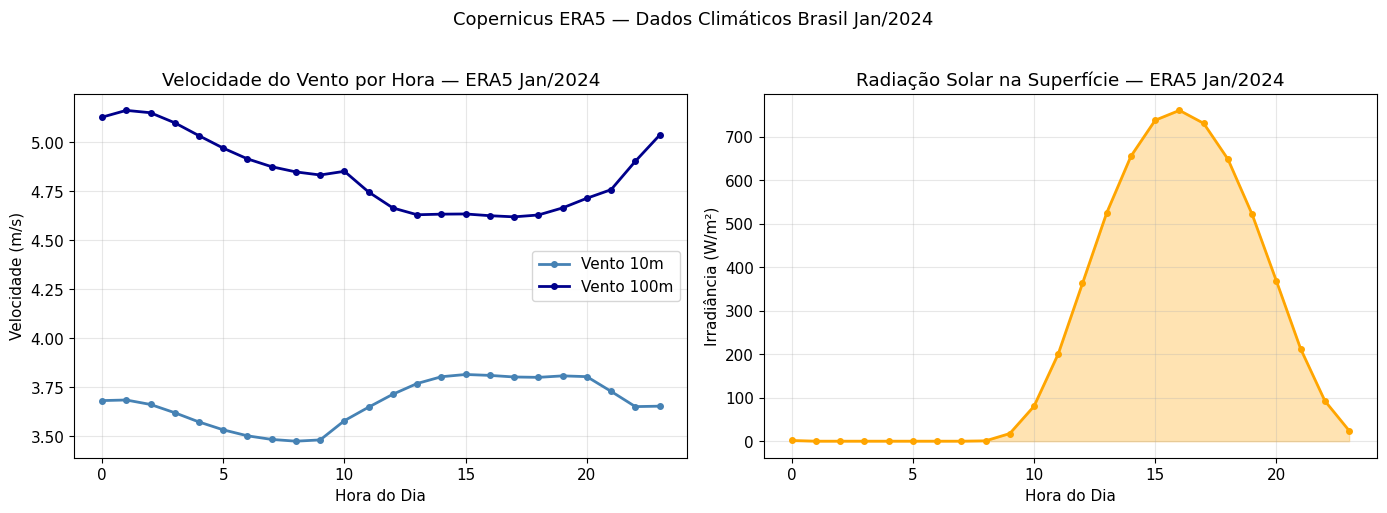

✅ Gráfico ERA5 salvo!


In [101]:
# Visualizando ERA5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_era5.groupby('hora')['vento_10m_ms'].mean(),
             color='steelblue', linewidth=2, marker='o', markersize=4, label='Vento 10m')
axes[0].plot(df_era5.groupby('hora')['vento_100m_ms'].mean(),
             color='darkblue', linewidth=2, marker='o', markersize=4, label='Vento 100m')
axes[0].set_title('Velocidade do Vento por Hora — ERA5 Jan/2024')
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('Velocidade (m/s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ssrd_hora = df_era5.groupby('hora')['ssrd_wm2'].mean()
axes[1].plot(ssrd_hora.index, ssrd_hora.values, color='orange', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(ssrd_hora.index, ssrd_hora.values, alpha=0.3, color='orange')
axes[1].set_title('Radiação Solar na Superfície — ERA5 Jan/2024')
axes[1].set_xlabel('Hora do Dia')
axes[1].set_ylabel('Irradiância (W/m²)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Copernicus ERA5 — Dados Climáticos Brasil Jan/2024', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/era5_climatico.png', dpi=150)
plt.show()
print('✅ Gráfico ERA5 salvo!')

## 4. Incorporando Dados Climáticos nos Modelos

In [102]:
# Mapeando regiões ONS para NASA
mapa_regioes = {
    'Nordeste':             'Nordeste',
    'Sudeste/Centro-Oeste': 'Sudeste',
    'Sul':                  'Sul',
    'Norte':                'Norte',
}

# Features NASA por região e hora
nasa_features = df_nasa.groupby(['regiao', 'hora'])[['irradiancia_nasa', 'temperatura_c', 'vento_nasa_ms', 'nuvens_pct']].mean().reset_index()

df_solar['regiao_nasa']  = df_solar['nom_subsistema'].map(mapa_regioes).fillna('Centro-Oeste')
df_eolica['regiao_nasa'] = df_eolica['nom_subsistema'].map(mapa_regioes).fillna('Centro-Oeste')

df_solar  = df_solar.merge(nasa_features, left_on=['regiao_nasa', 'hora'], right_on=['regiao', 'hora'], how='left')
df_eolica = df_eolica.merge(nasa_features, left_on=['regiao_nasa', 'hora'], right_on=['regiao', 'hora'], how='left')

# Features ERA5 por hora
era5_hora = df_era5.groupby('hora')[['vento_10m_ms', 'vento_100m_ms', 'ssrd_wm2']].mean().reset_index()

df_solar  = df_solar.merge(era5_hora, on='hora', how='left')
df_eolica = df_eolica.merge(era5_hora, on='hora', how='left')

print('✅ Dados climáticos incorporados!')
print(f'Solar:  {df_solar.shape}')
print(f'Eólica: {df_eolica.shape}')

✅ Dados climáticos incorporados!
Solar:  (56160, 46)
Eólica: (110160, 46)


## 5. Treinamento dos Modelos XGBoost

In [103]:
FEATURES_BASE = [
    'hora', 'mes', 'dia_semana', 'trimestre',
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_ano_sin', 'dia_ano_cos',
    'latitude', 'longitude', 'capacidade',
    'subsistema_enc', 'estado_enc',
]

FEATURES_CLIMA = FEATURES_BASE + [
    'irradiancia_nasa', 'temperatura_c', 'vento_nasa_ms', 'nuvens_pct',
    'vento_10m_ms', 'vento_100m_ms', 'ssrd_wm2'
]

def treinar_modelo(X, y, nome):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    modelo = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f'  {nome}: R²={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}')
    return modelo, y_test, y_pred, r2, mae, rmse

print('⏳ Treinando modelos...')
print('\n🌞 SOLAR:')
modelo_solar_base, yt_sb, yp_sb, r2_sb, mae_sb, rmse_sb = treinar_modelo(
    df_solar[FEATURES_BASE].fillna(0), df_solar['val_fatorcapacidade'], 'Sem dados climáticos')
modelo_solar, yt_s, yp_s, r2_s, mae_s, rmse_s = treinar_modelo(
    df_solar[FEATURES_CLIMA].fillna(0), df_solar['val_fatorcapacidade'], 'Com NASA + ERA5')

print('\n💨 EÓLICO:')
modelo_eolico_base, yt_eb, yp_eb, r2_eb, mae_eb, rmse_eb = treinar_modelo(
    df_eolica[FEATURES_BASE].fillna(0), df_eolica['val_fatorcapacidade'], 'Sem dados climáticos')
modelo_eolico, yt_e, yp_e, r2_e, mae_e, rmse_e = treinar_modelo(
    df_eolica[FEATURES_CLIMA].fillna(0), df_eolica['val_fatorcapacidade'], 'Com NASA + ERA5')

print('\n' + '='*60)
print('📊 RESUMO FINAL')
print('='*60)
print(f'🌞 Solar  — R² base: {r2_sb:.4f} → com clima: {r2_s:.4f} ({(r2_s-r2_sb)/r2_sb*100:+.1f}%)')
print(f'💨 Eólico — R² base: {r2_eb:.4f} → com clima: {r2_e:.4f} ({(r2_e-r2_eb)/r2_eb*100:+.1f}%)')

joblib.dump(modelo_solar,  '../models/modelo_solar.pkl')
joblib.dump(modelo_eolico, '../models/modelo_eolico.pkl')
print('\n✅ Modelos salvos em models/')

⏳ Treinando modelos...

🌞 SOLAR:
  Sem dados climáticos: R²=0.8718 | MAE=0.0534 | RMSE=0.0953
  Com NASA + ERA5: R²=0.8795 | MAE=0.0500 | RMSE=0.0924

💨 EÓLICO:
  Sem dados climáticos: R²=0.7255 | MAE=0.0969 | RMSE=0.1334
  Com NASA + ERA5: R²=0.7231 | MAE=0.0971 | RMSE=0.1339

📊 RESUMO FINAL
🌞 Solar  — R² base: 0.8718 → com clima: 0.8795 (+0.9%)
💨 Eólico — R² base: 0.7255 → com clima: 0.7231 (-0.3%)

✅ Modelos salvos em models/


## 6. Avaliação Visual

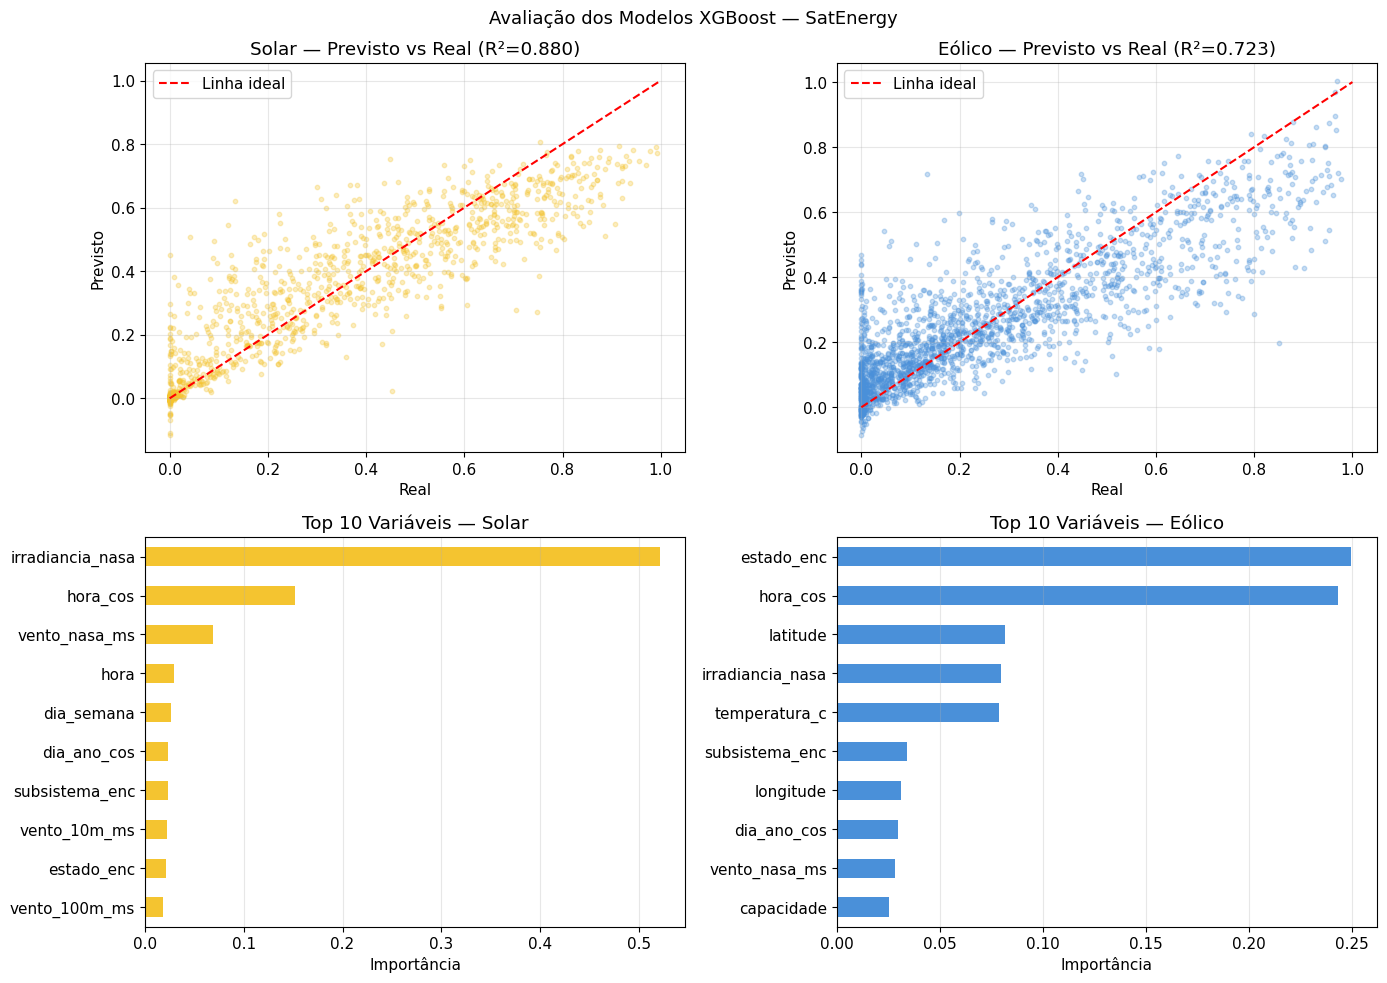

✅ Gráfico de avaliação salvo!


In [104]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Solar — Previsto vs Real
axes[0,0].scatter(yt_s[:2000], yp_s[:2000], alpha=0.3, color='#f4c430', s=10)
axes[0,0].plot([0,1], [0,1], 'r--', linewidth=1.5, label='Linha ideal')
axes[0,0].set_title(f'Solar — Previsto vs Real (R²={r2_s:.3f})')
axes[0,0].set_xlabel('Real')
axes[0,0].set_ylabel('Previsto')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Eólico — Previsto vs Real
axes[0,1].scatter(yt_e[:2000], yp_e[:2000], alpha=0.3, color='#4a90d9', s=10)
axes[0,1].plot([0,1], [0,1], 'r--', linewidth=1.5, label='Linha ideal')
axes[0,1].set_title(f'Eólico — Previsto vs Real (R²={r2_e:.3f})')
axes[0,1].set_xlabel('Real')
axes[0,1].set_ylabel('Previsto')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Importância Solar
imp_s = pd.Series(modelo_solar.feature_importances_, index=FEATURES_CLIMA).sort_values(ascending=True).tail(10)
imp_s.plot(kind='barh', ax=axes[1,0], color='#f4c430')
axes[1,0].set_title('Top 10 Variáveis — Solar')
axes[1,0].set_xlabel('Importância')
axes[1,0].grid(True, alpha=0.3, axis='x')

# Importância Eólico
imp_e = pd.Series(modelo_eolico.feature_importances_, index=FEATURES_CLIMA).sort_values(ascending=True).tail(10)
imp_e.plot(kind='barh', ax=axes[1,1], color='#4a90d9')
axes[1,1].set_title('Top 10 Variáveis — Eólico')
axes[1,1].set_xlabel('Importância')
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Avaliação dos Modelos XGBoost — SatEnergy', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/modelo_avaliacao.png', dpi=150)
plt.show()
print('✅ Gráfico de avaliação salvo!')